# STEP 01 — Problem Definition & Energy Data

**Smart Battery Energy Management — Reinforcement Learning Decision System**

Ez a notebook nem egy „importáld a kész pipeline-t és nézd meg az eredményt” wrapper. A cél az, hogy **celláról cellára** felépítsük a döntési problémát, megértsük az adatokat, a train/validation/test időbeli szétválasztását és azt, hogy egy RL agent pontosan milyen információból fog dönteni.

## Mit fogunk ebben a notebookban megcsinálni?

1. megfogalmazzuk az energetikai döntési problémát;
2. tisztázzuk az RL alapfogalmait az akkumulátoros példán;
3. betöltjük és ellenőrizzük az órás energia-idősorokat;
4. külön megvizsgáljuk az árat, fogyasztást és megújuló termelést;
5. időrendben szétválasztjuk a train / validation / test időszakot;
6. megmutatjuk, mit jelent a **future leakage** ebben a projektben;
7. létrehozunk egy konkrét 24 órás episode-ablakot, amelyet később az environment fog használni.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. RL fogalmak az akkumulátoros rendszerben

| Fogalom | Ebben a projektben |
|---|---|
| **Agent** | a vezérlő algoritmus, amely charge / idle / discharge döntést hoz |
| **Environment** | az energiarendszer + akkumulátor fizika + ár/demand/renewable idősor |
| **State / Observation** | SOC, ár, demand, renewable, hour-of-day (+ opcionális forecastok) |
| **Action** | töltés, semmittevés vagy kisütés |
| **Reward** | költség, csúcsterhelés, degradáció és constraint-ek kombinált következménye |
| **Policy** | az a szabály/függvény, amely state-ből actiont választ |
| **Episode** | alapértelmezésben 24 egymást követő óra |
| **Return** | egy episode során kapott rewardok összege |

A lényeg: a mostani action **megváltoztatja a későbbi SOC-t**, ezért a következő órák döntési lehetőségeit is. Emiatt ez szekvenciális optimalizálási probléma.

## 2. Miért nem egyszerű supervised learning?

Supervised learningnél tipikusan lenne egy célváltozó, például `optimal_action`, amely megmondja, hogy minden órában mi a helyes döntés. Itt ilyen ground-truth címke nincs.

Ha most kisütjük az akkumulátort, lehet, hogy az aktuális órában pénzt spórolunk, de este már nem marad energia egy sokkal drágább csúcshoz. Az agentnek tehát a **rövid távú jutalom és a hosszú távú következmény** között kell kompromisszumot tanulnia.

## 3. A szintetikus adatkészlet szerepe

Az első verzió saját, kontrollálható idősorral dolgozik. Ez szándékos: így pontosan tudjuk, mi kerül az environmentbe, és nem rejtjük el a tanulási logikát egy nagy külső benchmark mögé. A szintetikus profil napi és szezonális mintázatokat, zajt, megújuló termelést és döntési időpontban elérhető forecastokat is tartalmaz.

In [2]:
data_preview = full.head(10).copy()
display(data_preview)

print("Columns:")
for c in full.columns:
    print(" -", c)

,timestamp,electricity_price_eur_per_kwh,electricity_demand_kw,renewable_generation_kw,hour_of_day,day_of_week,demand_forecast_1h_kw,renewable_forecast_1h_kw,rolling_average_price_24h
0,2024-07-01 00:00:00,0.112899,44.164726,4.963247,0,0,43.453689,0.000000,0.112899
1,2024-07-01 01:00:00,0.103727,39.882054,0.159452,1,0,43.311614,0.000000,0.108313
2,2024-07-01 02:00:00,0.109841,45.709584,3.819218,2,0,43.884042,0.000000,0.108822
3,2024-07-01 03:00:00,0.112761,46.679056,0.000000,3,0,46.734445,0.000000,0.109807
4,2024-07-01 04:00:00,0.109132,38.431331,4.923360,4,0,44.816036,0.000000,0.109672
5,2024-07-01 05:00:00,0.111545,42.590233,0.957695,5,0,49.561366,0.000000,0.109984
6,2024-07-01 06:00:00,0.098014,50.267368,1.521757,6,0,50.465316,22.724369,0.108274
7,2024-07-01 07:00:00,0.092629,51.883896,20.463388,7,0,54.649741,40.514975,0.106318
8,2024-07-01 08:00:00,0.101111,54.142864,36.873058,8,0,52.543132,52.344518,0.105740
9,2024-07-01 09:00:00,0.097860,50.204449,54.642462,9,0,52.133266,69.417815,0.104952


Columns:
 - timestamp
 - electricity_price_eur_per_kwh
 - electricity_demand_kw
 - renewable_generation_kw
 - hour_of_day
 - day_of_week
 - demand_forecast_1h_kw
 - renewable_forecast_1h_kw
 - rolling_average_price_24h


### Adatséma — mit jelent egy sor?

Egy sor **egy órát** reprezentál. A `timestamp` az időpont, az `electricity_price_eur_per_kwh` az import energia ára, az `electricity_demand_kw` a fogyasztási teljesítmény, a `renewable_generation_kw` pedig a lokális megújuló termelés. A forecast oszlopok nem a jövő tökéletes ismeretét jelentik: zajos, döntési időpontban rendelkezésre álló becslések.

In [3]:
schema = pd.DataFrame({
    "dtype": full.dtypes.astype(str),
    "missing": full.isna().sum(),
    "unique": full.nunique(),
})
display(schema)
print("Duplicated timestamps:", full["timestamp"].duplicated().sum())

,dtype,missing,unique
timestamp,datetime64[ns],0,8760
electricity_price_eur_per_kwh,float64,0,8760
electricity_demand_kw,float64,0,8760
renewable_generation_kw,float64,0,6304
hour_of_day,int64,0,24
day_of_week,int64,0,7
demand_forecast_1h_kw,float64,0,8760
renewable_forecast_1h_kw,float64,0,6333
rolling_average_price_24h,float64,0,8760


Duplicated timestamps: 0


## 4. Az első hét energiaára

Az árprofil teremti meg az **energy arbitrage** lehetőségét: elvileg olcsó órákban érdemes tölteni, drága órákban kisütni. De ez önmagában még nem policy, mert közben a SOC, demand, renewable és a későbbi lehetőségek is számítanak.

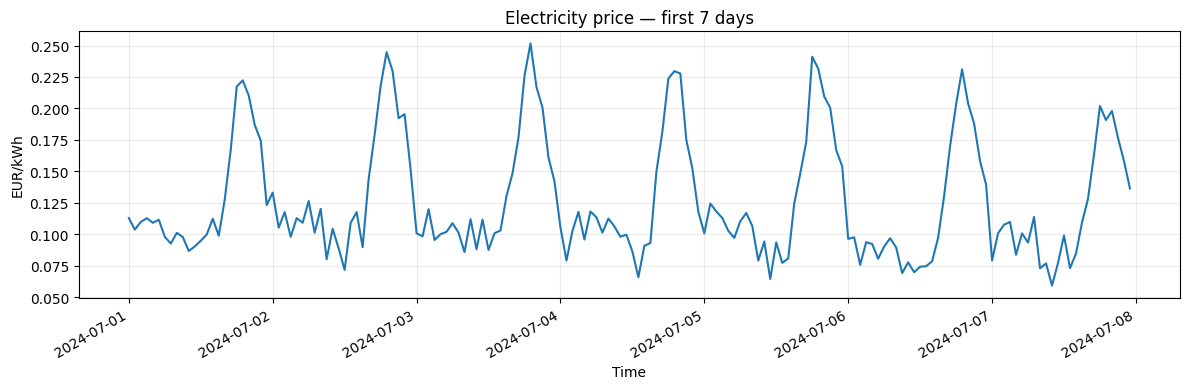

In [4]:
sample = full.iloc[:24*7].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample["timestamp"], sample["electricity_price_eur_per_kwh"], linewidth=1.5)
ax.set_title("Electricity price — first 7 days")
ax.set_ylabel("EUR/kWh")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_01_price_first_week.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. Fogyasztás és megújuló termelés

A battery controller nem közvetlenül az árat optimalizálja. A hálózati energiaigény a demand, renewable és battery power együttes eredménye. Ha például délben magas a napelemes termelés, a töltés növelheti a helyben felhasznált megújuló energia arányát.

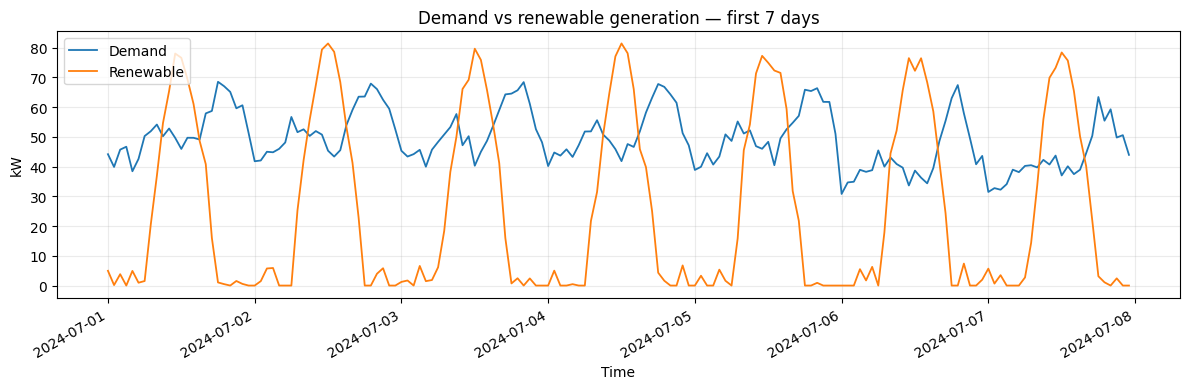

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample["timestamp"], sample["electricity_demand_kw"], label="Demand", linewidth=1.3)
ax.plot(sample["timestamp"], sample["renewable_generation_kw"], label="Renewable", linewidth=1.3)
ax.set_title("Demand vs renewable generation — first 7 days")
ax.set_ylabel("kW")
ax.set_xlabel("Time")
ax.legend()
ax.grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_02_demand_renewable.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Chronological train / validation / test split

Idősoros döntési problémánál **nem shuffle-öljük össze** a teljes évet. A validation és test időszak időben a training után marad. Ez sokkal közelebb áll a valós deploymenthez: a policy a múltból tanul, majd későbbi, nem látott időszakokon bizonyít.

In [6]:
split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train), "start": train.timestamp.min(), "end": train.timestamp.max()},
    {"split": "validation", "rows": len(val), "start": val.timestamp.min(), "end": val.timestamp.max()},
    {"split": "test", "rows": len(test), "start": test.timestamp.min(), "end": test.timestamp.max()},
])
display(split_summary)

,split,rows,start,end
0,train,6132,2024-07-01 00:00:00,2025-03-13 11:00:00
1,validation,1314,2025-03-13 12:00:00,2025-05-07 05:00:00
2,test,1314,2025-05-07 06:00:00,2025-06-30 23:00:00


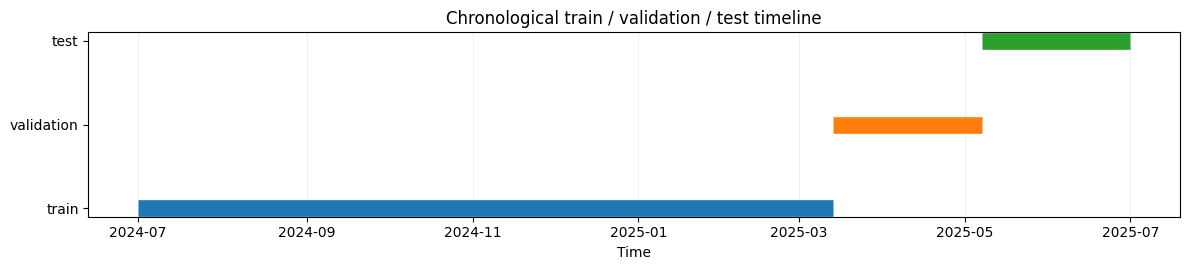

In [7]:
fig, ax = plt.subplots(figsize=(12, 2.8))
for y, row in split_summary.reset_index(drop=True).iterrows():
    ax.plot([row["start"], row["end"]], [y, y], linewidth=12, solid_capstyle="butt")
ax.set_yticks(range(len(split_summary)), split_summary["split"])
ax.set_title("Chronological train / validation / test timeline")
ax.set_xlabel("Time")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_03_temporal_split.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Future leakage — mit tilos megadni az agentnek?

A `t` időpontban az agent **nem kaphatja meg a `t+1` óra tényleges demandját vagy renewable termelését**, mert az a döntés pillanatában még nem ismert. Forecast használható, ha azt úgy kezeljük, mint egy rendelkezésre álló előrejelzést.

Ez fontos különbség: `forecasted_demand` legitim feature lehet; `future_actual_demand` leakage.

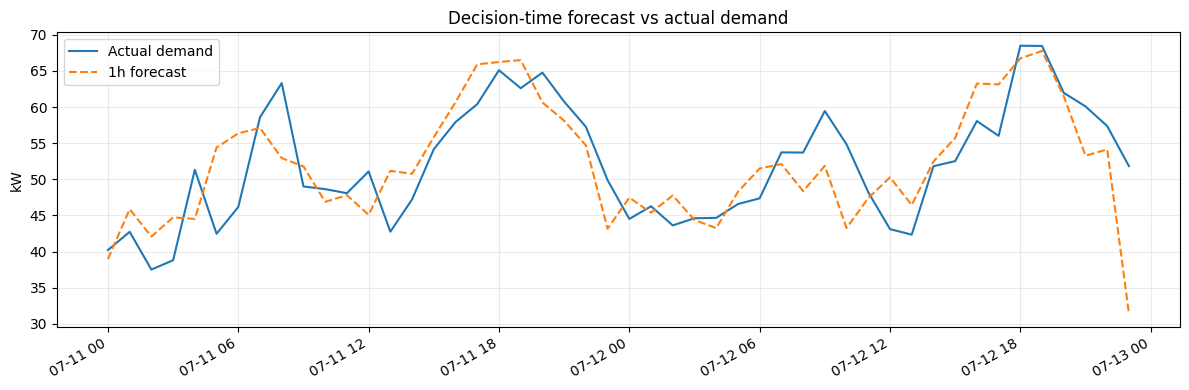

In [8]:
forecast_sample = full.iloc[24*10:24*12].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(forecast_sample["timestamp"], forecast_sample["electricity_demand_kw"], label="Actual demand")
ax.plot(forecast_sample["timestamp"], forecast_sample["demand_forecast_1h_kw"], label="1h forecast", linestyle="--")
ax.set_title("Decision-time forecast vs actual demand")
ax.set_ylabel("kW")
ax.legend()
ax.grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_04_forecast_vs_actual.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Egy 24 órás episode konkrétan

A training során az environment különböző kezdőpontokról 24 órás ablakokat választ. Az episode végén a környezet terminál. A következő episode új kezdőponttal indulhat, így az agent sok különböző napi helyzetet tapasztal.

In [9]:
episode_hours = int(cfg["environment"]["episode_hours"])
start = 24 * 30
episode = train.iloc[start:start+episode_hours].copy()
episode[["timestamp", "electricity_price_eur_per_kwh", "electricity_demand_kw", "renewable_generation_kw", "hour_of_day"]].head(24)

,timestamp,electricity_price_eur_per_kwh,electricity_demand_kw,renewable_generation_kw,hour_of_day
720,2024-07-31 00:00:00,0.110751,42.908232,0.000000,0
721,2024-07-31 01:00:00,0.108649,46.846038,0.000000,1
722,2024-07-31 02:00:00,0.101375,36.036153,0.000000,2
723,2024-07-31 03:00:00,0.080539,38.906379,0.455178,3
724,2024-07-31 04:00:00,0.099463,41.747781,0.000000,4
725,2024-07-31 05:00:00,0.100317,51.459354,1.855207,5
726,2024-07-31 06:00:00,0.113260,50.788931,0.000000,6
727,2024-07-31 07:00:00,0.111034,55.377661,14.586618,7
728,2024-07-31 08:00:00,0.105518,50.574486,35.954987,8
729,2024-07-31 09:00:00,0.113239,49.378049,44.925410,9


In [10]:
row = episode.iloc[0]
initial_state = {
    "battery_state_of_charge": cfg["battery"]["initial_soc"],
    "electricity_price": row["electricity_price_eur_per_kwh"],
    "electricity_demand": row["electricity_demand_kw"],
    "renewable_generation": row["renewable_generation_kw"],
    "hour_of_day": int(row["hour_of_day"]),
}
initial_state

{'battery_state_of_charge': 0.5,
 'electricity_price': np.float64(0.1107507020422686),
 'electricity_demand': np.float64(42.90823243901176),
 'renewable_generation': np.float64(0.0),
 'hour_of_day': 0}

## 9. Mit viszünk tovább a következő stepbe?

Most már van egy fizikailag értelmezhető órás adatsorunk és tiszta időbeli splitünk. A következő notebookban még **nem tanítunk agentet**: előbb részletes EDA-val megértjük, milyen mintázatokkal kell majd a baseline-oknak és az RL policyknak megküzdeniük.

**Fontos mérnöki sorrend:** data understanding → environment design → baseline → RL. Nem fordítva.